**Practical 13: >> Multi-Variable Time-Series Visualization**
**Objective:** To analyze multiple variables over time.
**Tasks:**
- Create a time-series visualization with multiple variables
- Analyse observed patterns

**Outcome:** Students will interpret multi-dimensional time-series data.


**Step 1:** Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

**Step 2:** Load and Prepare Dataset

In [2]:
# Load dataset
df = pd.read_csv("student_extended.csv")

# Clean columns
df.columns = df.columns.str.strip().str.lower()

# If academic_year not present, create it
if "academic_year" not in df.columns:
    years = ["2023", "2024", "2025"]
    df["academic_year"] = np.random.choice(years, size=len(df))

# Convert numeric columns
df["percentage"] = pd.to_numeric(df["percentage"], errors="coerce")
df["sgpa"] = pd.to_numeric(df["sgpa"], errors="coerce")
df["attendance_percentage"] = pd.to_numeric(df["attendance_percentage"], errors="coerce")

# Remove missing values
df = df.dropna(subset=["percentage", "sgpa", "attendance_percentage"])

**Step 3:** Aggregate Data Year-wise

In [3]:
yearly_summary = df.groupby("academic_year").agg({
    "percentage": "mean",
    "sgpa": "mean",
    "attendance_percentage": "mean"
}).sort_index()

print(yearly_summary)

               percentage      sgpa  attendance_percentage
academic_year                                             
2023            67.213688  8.053452              79.767400
2024            66.449951  8.030123              79.606324
2025            66.878862  7.882276              79.882222


**Step 4:** Create Multi-Variable Time-Series Plot

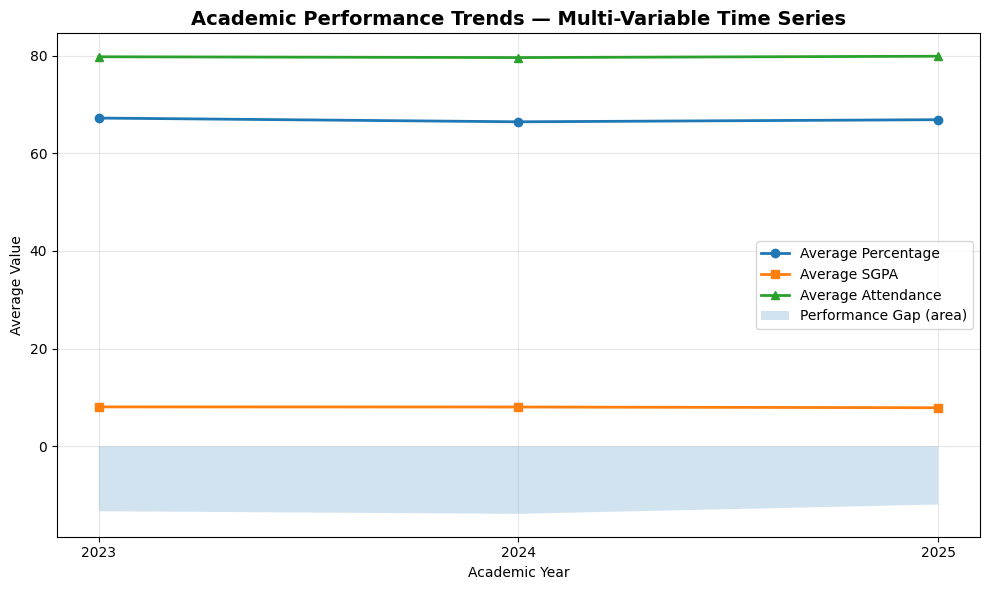

In [4]:
plt.figure(figsize=(10,6))

# Percentage Line
plt.plot(yearly_summary.index,
         yearly_summary["percentage"],
         marker="o",
         linewidth=2,
         label="Average Percentage")

# SGPA Line
plt.plot(yearly_summary.index,
         yearly_summary["sgpa"],
         marker="s",
         linewidth=2,
         label="Average SGPA")

# Attendance Line
plt.plot(yearly_summary.index,
         yearly_summary["attendance_percentage"],
         marker="^",
         linewidth=2,
         label="Average Attendance")

# Shade performance gap (Percentage - SGPA scaled)
plt.fill_between(
    yearly_summary.index,
    yearly_summary["percentage"] - yearly_summary["sgpa"]*10,
    alpha=0.2,
    label="Performance Gap (area)"
)

plt.title("Academic Performance Trends — Multi-Variable Time Series",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Academic Year")
plt.ylabel("Average Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**From the time-series visualization:**
- Trends in academic performance can be observed across years.
- If percentage and SGPA rise together, it indicates consistent academic improvement.
- Attendance trends may influence overall performance.
- Parallel movement of lines suggests positive correlation.
- Diverging trends indicate independent performance factors.

**This multi-variable time-series analysis helps in:**
- Monitoring institutional academic trends
- Identifying improvement or decline periods
- Comparing performance indicators simultaneously
- Supporting data-driven academic decisions